# Binary Tree Sandbox

In [1]:
import itertools
import logging

import matplotlib.pyplot as plt
import networkx as nx

logger = logging.getLogger()


class TreeNode:
    """Binary Tree"""

    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

    def __repr__(self):
        return f"N({self.val})"


def make_node(value):
    if value is None:
        return None
    return TreeNode(value)


def breadth_first_build(seq):
    if not seq:
        return None

    sides = itertools.cycle(["left", "right"])
    seq = iter(seq)
    root = make_node(next(seq))
    que = [root]

    for side, value in zip(sides, seq):
        node = make_node(value)
        setattr(que[0], side, node)
        if node:
            que.append(node)
        if side == "right":
            que.pop(0)

    return root


def draw_tree(root):
    if not root:
        print("Empty Tree")
        return

    G = nx.DiGraph()
    pos = {}

    def parse_tree(node, x=0, y=0, layer=1):
        if node:
            node_id = id(node)
            # Store the node value as a label attribute
            G.add_node(node_id, label=node.val)
            pos[node_id] = (x, y)

            # Adjust spacing dynamically based on the current depth layer
            width = 1.0 / (2**layer)

            if node.left:
                left_id = id(node.left)
                G.add_edge(node_id, left_id)
                parse_tree(node.left, x - width, y - 1, layer + 1)

            if node.right:
                right_id = id(node.right)
                G.add_edge(node_id, right_id)
                parse_tree(node.right, x + width, y - 1, layer + 1)

    parse_tree(root)

    # Extract labels
    labels = nx.get_node_attributes(G, "label")

    # Plotting using matplotlib
    plt.figure(figsize=(6, 4))
    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=800,
        node_color="lightblue",
        font_size=10,
        font_weight="bold",
        arrows=False,
    )
    plt.show()

In [6]:
t = breadth_first_build(range(1, 6))

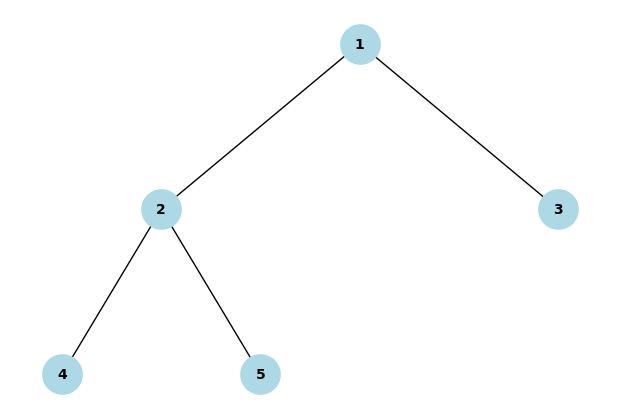

In [7]:
draw_tree(t)

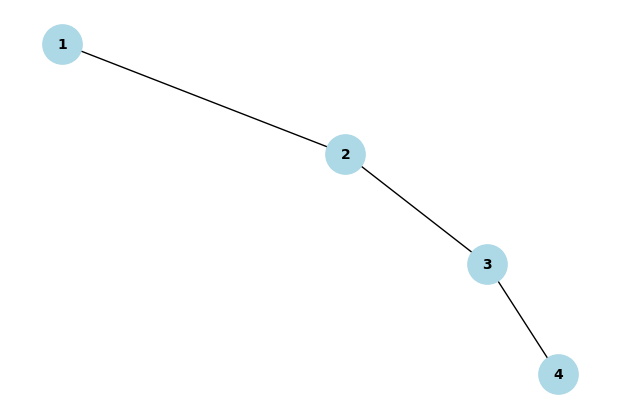

In [9]:
draw_tree(breadth_first_build([1, None, 2, None, 3, None, 4]))

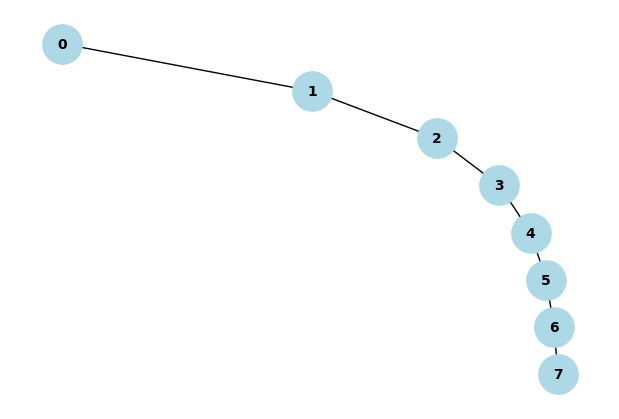

In [14]:
def right_skewed(n: int):
    seq = itertools.chain.from_iterable(zip(range(n), itertools.repeat(None)))
    return breadth_first_build(seq)


draw_tree(right_skewed(8))